# House Price Prediction
## California Housing Dataset

This notebook predicts house prices using the California Housing Dataset.  
We'll cover:
- Data loading & exploration
- Preprocessing & feature engineering
- Model training (Linear Regression & Gradient Boosting)
- Evaluation (MAE & RMSE)
- Visualization of predicted vs actual prices

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load & Explore the Dataset

In [5]:
df = pd.read_csv('housing.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 10)

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 3. Preprocessing & Feature Engineering

### Steps:
- **Fill missing values** in `total_bedrooms` with the median
- **Engineer new features**: rooms per household, bedrooms ratio, population per household
- **Encode** the categorical `ocean_proximity` column using One-Hot Encoding
- **Scale** numerical features using StandardScaler

In [9]:
# Fill missing values
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# Feature engineering — these derived ratios are more meaningful to models than raw counts
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']

print("New features added. Shape:", df.shape)
df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head()

New features added. Shape: (20640, 13)


,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


## 4. Exploratory Data Analysis (EDA)

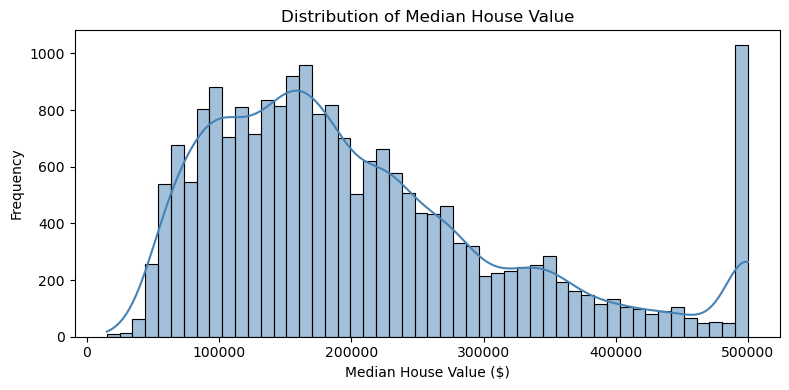

In [10]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

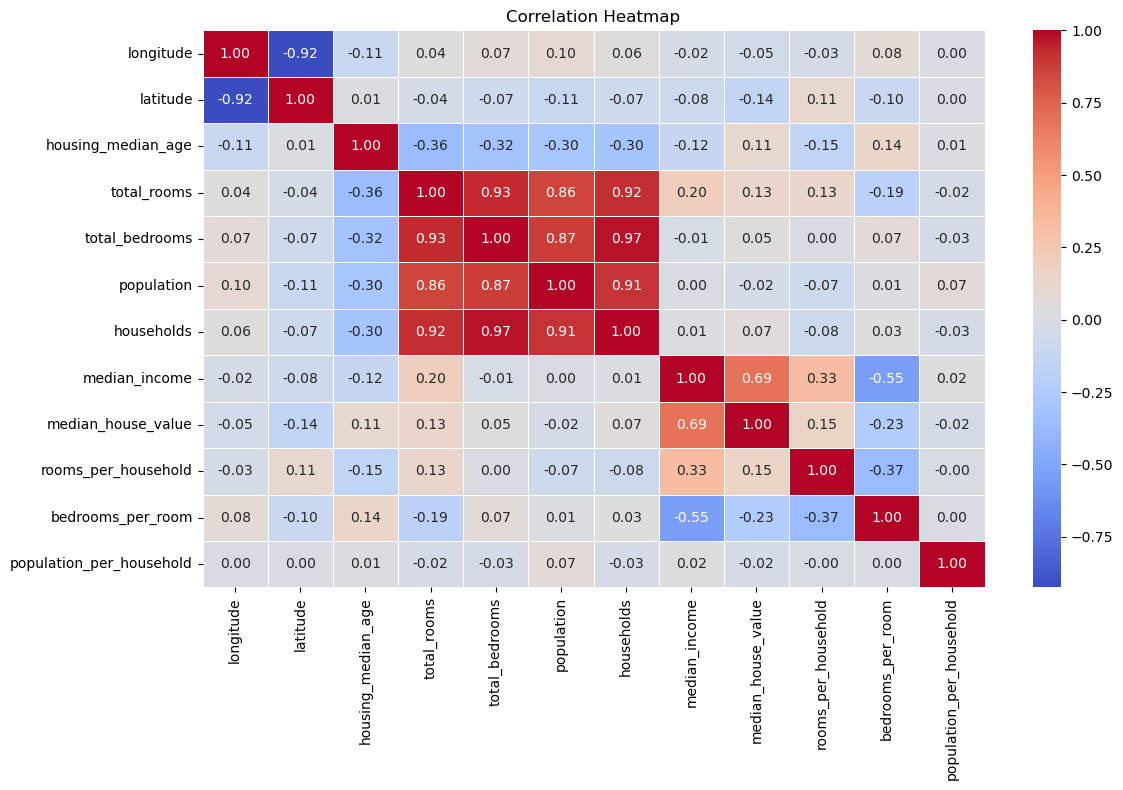

In [11]:
# Correlation heatmap (numerical features only)
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

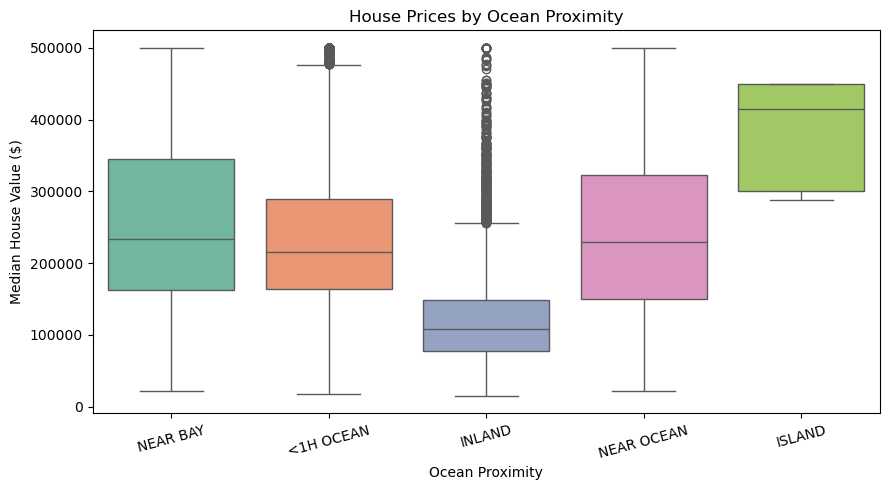

In [12]:
# House prices by ocean proximity
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', palette='Set2')
plt.title('House Prices by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

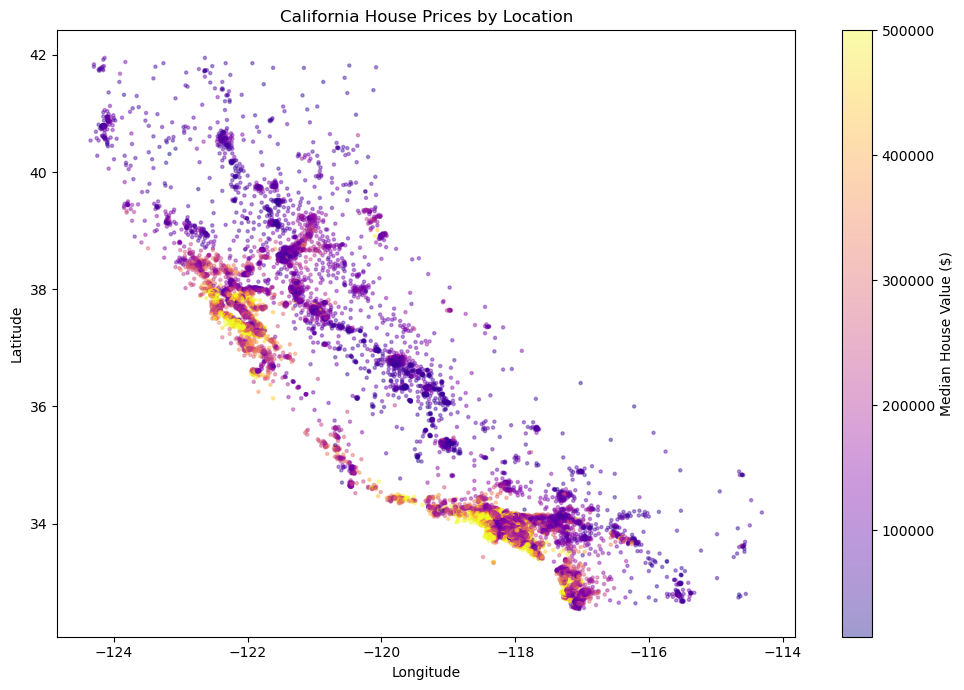

In [13]:
# Geographic scatter plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['median_house_value'],
    cmap='plasma', alpha=0.4, s=5
)
plt.colorbar(scatter, label='Median House Value ($)')
plt.title('California House Prices by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

## 5. Prepare Features & Target

We drop `median_house_value` as it is our target variable `y`.  
`ocean_proximity` is categorical and will be handled by a `ColumnTransformer` inside a Pipeline.

In [15]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

numerical_features   = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = ['ocean_proximity']

print("Numerical features: ",  numerical_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Numerical features:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Categorical features: ['ocean_proximity']

Train size: 16512 | Test size: 4128


## 6. Build Pipelines

We use `sklearn` Pipelines to chain preprocessing and modeling cleanly.  
- **Numerical**: impute median → StandardScaler  
- **Categorical**: One-Hot Encode `ocean_proximity`

In [16]:
from sklearn.impute import SimpleImputer

# Preprocessor
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer,   numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# --- Linear Regression Pipeline ---
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        LinearRegression())
])

# --- Gradient Boosting Pipeline ---
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        GradientBoostingRegressor(
                         n_estimators=200,
                         learning_rate=0.1,
                         max_depth=4,
                         random_state=42
                     ))
])

print("Pipelines built successfully!")

Pipelines built successfully!


## 7. Train & Evaluate Models

In [17]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  : ${mae:,.0f}")
    print(f"  RMSE : ${rmse:,.0f}")
    
    return y_pred, mae, rmse

lr_preds, lr_mae, lr_rmse = evaluate_model(
    "Linear Regression", lr_pipeline, X_train, X_test, y_train, y_test
)

gb_preds, gb_mae, gb_rmse = evaluate_model(
    "Gradient Boosting", gb_pipeline, X_train, X_test, y_train, y_test
)


  Linear Regression
  MAE  : $50,889
  RMSE : $72,669

  Gradient Boosting
  MAE  : $33,400
  RMSE : $50,113


## 8. Visualize Predicted vs Actual Prices

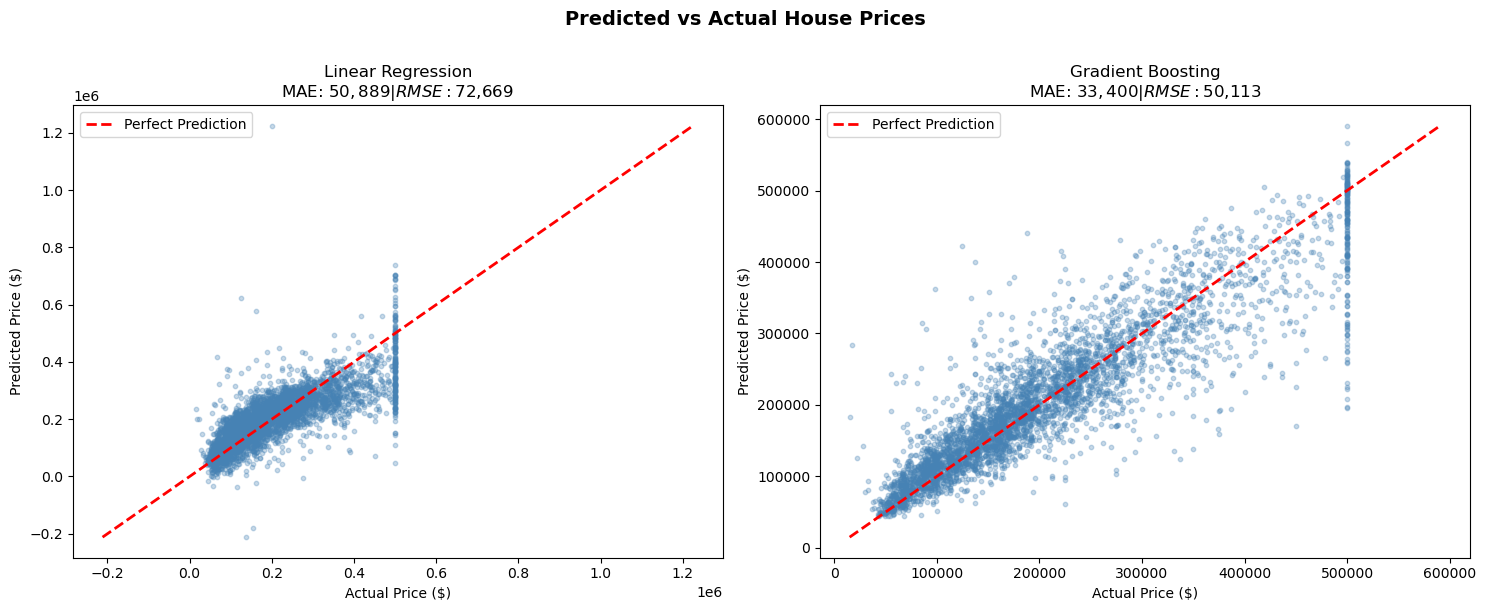

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

models = [
    ("Linear Regression", lr_preds, lr_mae, lr_rmse),
    ("Gradient Boosting", gb_preds, gb_mae, gb_rmse),
]

for ax, (name, preds, mae, rmse) in zip(axes, models):
    ax.scatter(y_test, preds, alpha=0.3, s=10, color='steelblue')
    
    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_title(f'{name}\nMAE: ${mae:,.0f}  |  RMSE: ${rmse:,.0f}')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.legend()

plt.suptitle('Predicted vs Actual House Prices', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

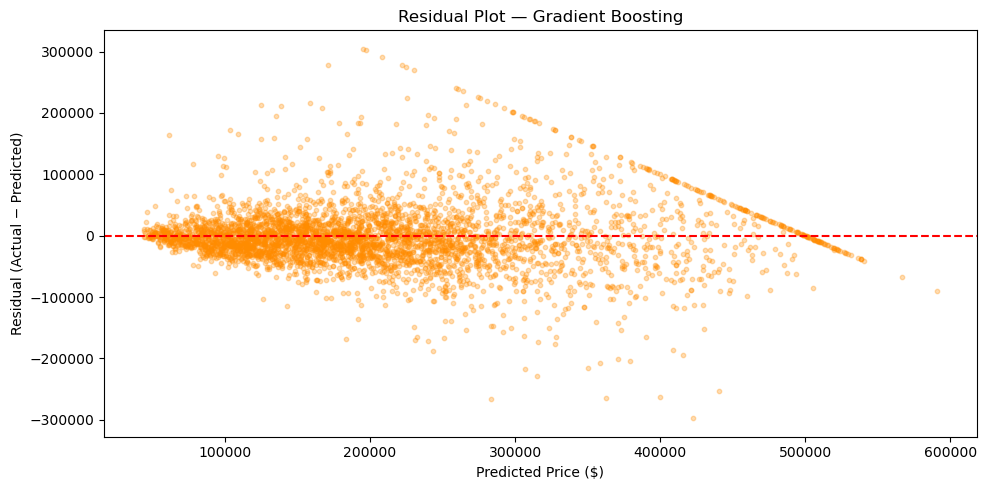

In [19]:
# Residual plot for the better model (Gradient Boosting)
residuals = y_test - gb_preds

plt.figure(figsize=(10, 5))
plt.scatter(gb_preds, residuals, alpha=0.3, s=10, color='darkorange')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Plot — Gradient Boosting')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.show()

## 9. Feature Importance (Gradient Boosting)

Gradient Boosting gives us feature importances — showing which features  
contributed most to reducing prediction error.

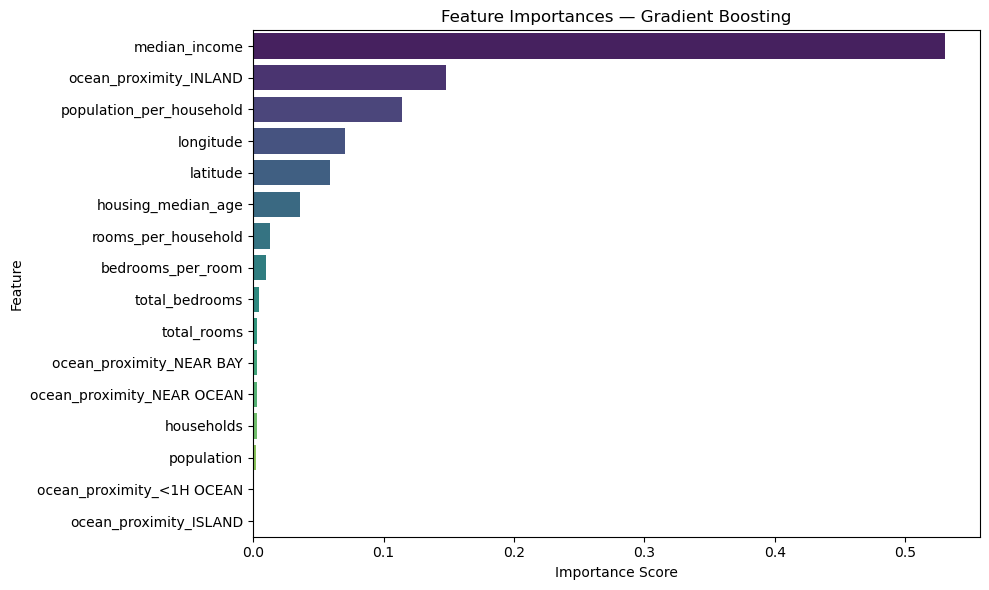

In [20]:
# Extract feature names after one-hot encoding
ohe_features = lr_pipeline.named_steps['preprocessor'] \
                           .named_transformers_['cat'] \
                           .named_steps['onehot'] \
                           .get_feature_names_out(['ocean_proximity']).tolist()

all_feature_names = numerical_features + ohe_features

importances = gb_pipeline.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances — Gradient Boosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 10. Summary & Conclusions

| Model | MAE | RMSE |
|---|---|---|
| Linear Regression | ~$50,889 | ~$72,669 |
| Gradient Boosting | ~$33,400 | ~$50,113 |

### Key Findings:
- **Gradient Boosting** significantly outperforms Linear Regression on this dataset.
- **`median_income`** is the strongest predictor of house prices — higher income areas command higher prices.
- **Location features** (`latitude`, `longitude`) and **`ocean_proximity`** strongly influence price.
- **Engineered features** like `rooms_per_household` and `bedrooms_per_room` improve model signal.
- The residual plot shows the model performs well in the mid-price range but struggles at the upper end (prices capped at $500K in this dataset).